In [1]:
%load_ext autoreload
%autoreload 2

import os, sys
import matplotlib.pyplot as plt

sys.path.insert(0, "src")

from pandas import DataFrame
from analytics.metrics.time import TimeMetrics
from spec.enums import MainTableColumns as Cols
from spec.spec_definition import PS2Versions
import pandas as pd

In [23]:
from analytics.dataset_config import Granularity
from datasets.codeworkout.configs import S19, F19

config = S19

idle_gap = None
break_gap = None
if config.granularity == Granularity.Submission:
    idle_gap = 5 * 60  # 5 minutes
    break_gap = 30 * 60  # 30 minutes
elif config.granularity == Granularity.Edit or config.granularity == Granularity.Keystroke:
    idle_gap = 30
    break_gap = 3 * 60 # 3 minutes
else:
    raise NotImplementedError(f"{config.granularity} granularity has not been determined.")

In [8]:
locals().update(config.__dict__)

In [11]:
# Shorten some configs for convenience
problem_id_col = config.primary_problem_grouping_column
timestamp_col = config.primary_timestamp_column

config_path = os.path.join("sample_data_configs", f"{config.name}.yaml")

In [ ]:
# TODO: Replace this with config files!

from analytics.preprocessors.edwards import TimeStampToDateTimePreprocessor, ClassSubsetPreprocessor
from analytics.preprocessors.codebench import YAMLLinkURLPreprocessor, CodeBenchAddParentEventIDs
from analytics.preprocessors.codeworkout import CodeWorkoutExtractErrorTypesPreprocessor
from analytics.ps2_dataset import SortPreprocessor, FilterPreprocessor
from spec.enums import EventType

config_path = None
problem_id_col = None
timestamp_col = None
idle_gap = None
break_gap = None
main_table_preprocessors = []
link_table_preprocessors = []
submit_event = EventType.Submit
grades_link_table = "Subject"
grades_col = None
start_time = None
end_time = None
early_percentage = None
assignment_ids = None
compile_error_type_column = Cols.CompileMessageType
compile_event = EventType.Compile
compile_error_event = EventType.CompileError
output_suffix = ''

falconcode_f21_config = {
    "config_path": "sample_data_configs/falconcode.yaml",
    "problem_id_col": Cols.ProblemID,
    "timestamp_col": Cols.ServerTimestamp,
    "idle_gap": 5 * 60,
    "break_gap": 30 * 60,
    "mt_preprocessing_steps": [
        FilterPreprocessor(Cols.TermID, "Fall 2021"),
    ],
    "early_percentage": 0.25,
}

# Note: Only Fall has compilation data; spring has no Run.Program events!
edwards_s19_config = {
    "config_path": "sample_data_configs/edwards2019.yaml",
    "problem_id_col": Cols.AssignmentID,
    "timestamp_col": Cols.ClientTimestamp,
    "idle_gap": 30,
    "break_gap": 3 * 60,
    "mt_preprocessing_steps": [
        # Don't need this, since I've done and cached it
        # AddErrors2021Preprocessor(),
        TimeStampToDateTimePreprocessor(),
        # Make sure this comes last so Fall is correct
        ClassSubsetPreprocessor("Spring"),
    ],
    # Compile error info is stored in the Run.Program event itself
    "compile_event": EventType.RunProgram,
    "end_time": "2019-02-25 00:00:00",
    "early_percentage": 0.23,
    "assignment_ids": ["p4s", "p5s"],  # Only 2 assignments
    "grades_col": "exam2",
    "output_suffix": "-s19",
}

edwards_f19_config = edwards_s19_config.copy()
edwards_f19_config["mt_preprocessing_steps"] = edwards_s19_config["mt_preprocessing_steps"].copy()
edwards_f19_config["mt_preprocessing_steps"][-1] = ClassSubsetPreprocessor("Fall")
edwards_f19_config["end_time"] = "2019-10-13 00:00:00"
edwards_f19_config["assignment_ids"] = ["p4f", "p5f"]
edwards_f19_config["early_percentage"] = 0.42
edwards_f19_config["output_suffix"] = "-f19"

edwards2021_config = {
    "config_path": "sample_data_configs/edwards2021.yaml",
    "problem_id_col": Cols.AssignmentID,
    "timestamp_col": Cols.ClientTimestamp,
    "idle_gap": 30,
    "break_gap": 3 * 60,
    "mt_preprocessing_steps": [
        # Don't need this, since I've done and cached it
        # AddErrors2021Preprocessor(),
        TimeStampToDateTimePreprocessor(),
    ],
    # Compile error info is stored in the Run.Program event itself
    "compile_event": EventType.RunProgram,
    "end_time": "2022-01-01 00:00:00",
    "early_percentage": 0.4,
    "assignment_ids": ["Assign6", "Assign7"],  # Only 2 assignments
    "grades_col": "FinalScore",
}

cwo_s19_config = {
    "config_path": "sample_data_configs/cwo_s19.yaml",
    "problem_id_col": Cols.ProblemID,
    "timestamp_col": Cols.ServerTimestamp,
    "idle_gap": 5 * 60,
    "break_gap": 30 * 60,
    "mt_preprocessing_steps": [
        SortPreprocessor(),
        CodeWorkoutExtractErrorTypesPreprocessor(),
    ],
    "submit_event": EventType.RunProgram,
    "grades_col": "X-Grade",
    "early_percentage": 0.33,
}

cwo_f19_config = {
    "config_path": "sample_data_configs/cwo_f19.yaml",
    "problem_id_col": Cols.ProblemID,
    "timestamp_col": Cols.ServerTimestamp,
    "idle_gap": 5 * 60,
    "break_gap": 30 * 60,
    "mt_preprocessing_steps": [
        SortPreprocessor(),
        CodeWorkoutExtractErrorTypesPreprocessor(),
    ],
    "submit_event": EventType.RunProgram,
    "grades_col": "X-Grade",
    "early_percentage": 0.25,
}

codebench2024_config = {
    "config_path": "sample_data_configs/codebench2024.yaml",
    "problem_id_col": Cols.ProblemID,
    "timestamp_col": Cols.ServerTimestamp,
    "idle_gap": 30,
    "break_gap": 3 * 60,
    "link_preprocessing_steps": [YAMLLinkURLPreprocessor(True)],
    "mt_preprocessing_steps": [
        CodeBenchAddParentEventIDs(),
    ],
    "grades_link_table": "CourseSubject",
    "grades_col": "final-grade",
    "start_time": "2024-09-01 00:00:00",
    "early_percentage": 0.28,
    "compile_error_type_col": "ProgramErrorOutput",
    "compile_event": EventType.Submit,
    "compile_error_event": EventType.RunTest,
}

# config = cwo_f19_config
# config = cwo_s19_config
# config = codebench2024_config
# config = edwards2021_config
# config = edwards_s19_config
# config = edwards_f19_config
config = falconcode_f21_config
locals().update(config)

In [12]:
from database.config import PS2DataConfig

spec = PS2Versions.v1_0.load()

data_config = PS2DataConfig.from_yaml(config_path, spec)


In [13]:
from analytics.ps2_dataset import PS2Dataset

dataset = PS2Dataset(spec, data_config)
for i, step in enumerate(main_table_preprocessors):
    dataset.main_table_preprocessors.insert(i, step)
for i, step in enumerate(link_table_preprocessors):
    dataset.link_table_preprocessors.insert(i, step)

In [14]:
main_table = dataset.get_main_table()
main_table.head()

,Order,SubjectID,ToolInstances,ServerTimestamp,ServerTimezone,CourseID,CourseSectionID,AssignmentID,ProblemID,Attempt,CodeStateID,IsEventOrderingConsistent,EventType,Score,Compile.Result,CompileMessageType,CompileMessageData,EventID,ParentEventID,SourceLocation
0,0,f40a635828e2bffd0a598a7ed621fc93,Java 8; CodeWorkout,2019-03-20 19:34:25,0,CS 1,1,492.0,32,25,548938774dc948448b0bb51139bbcae3a3966ab8,True,Run.Program,1.0,NaN,None,NaN,32-84779,NaN,NaN
1,1,f40a635828e2bffd0a598a7ed621fc93,Java 8; CodeWorkout,2019-03-20 19:34:25,0,CS 1,1,492.0,32,25,548938774dc948448b0bb51139bbcae3a3966ab8,True,Compile,NaN,Success,None,NaN,32-84780,32-84779,NaN
2,2,f18374bf891c9af64c8570448824202d,Java 8; CodeWorkout,2019-03-20 21:02:00,0,CS 1,2,492.0,32,1,20dc599067ac07408b5636973fc6b8a37db9af32,True,Run.Program,1.0,NaN,None,NaN,32-84781,NaN,NaN
3,3,f18374bf891c9af64c8570448824202d,Java 8; CodeWorkout,2019-03-20 21:02:00,0,CS 1,2,492.0,32,1,20dc599067ac07408b5636973fc6b8a37db9af32,True,Compile,NaN,Success,None,NaN,32-84782,32-84781,NaN
4,4,4d230b683bf9840553ae57f4acc96e81,Java 8; CodeWorkout,2019-03-20 21:13:09,0,CS 1,1,492.0,32,1,23c57b36002c4d482df3d25f97778f74a2ed581a,True,Run.Program,0.0,NaN,None,NaN,32-84783,NaN,NaN


In [15]:
main_table[problem_id_col].unique()

array([ 32, 106, 234,  56,  43,  13,  12, 232,  64,  45,  51,  48, 233,
        41,   5, 235,  25, 236, 118, 104,  67,  37,  36, 107,  57, 108,
        21,  71, 112,  70, 128,   1,  49, 102,   3,  24, 100,  28,  31,
        44, 101,  38,  40,  22,  34,  46,  33,  39,  17,  20])

In [16]:
bad_assignment_ids = [407610653, 1147927607, 1407437764]
if Cols.AssignmentID in main_table.columns:
    main_table = main_table[~main_table[Cols.AssignmentID].isin(bad_assignment_ids)]

In [17]:
if start_time is not None:
    main_table = main_table[main_table[timestamp_col] >= start_time]
if end_time is not None:
    main_table = main_table[main_table[timestamp_col] <= end_time]

In [18]:
if "X-ClassID" in main_table.columns:
    class_counts = main_table["X-ClassID"].value_counts()
    print(class_counts)
    min_count = 1000
    invalid_class_ids = class_counts[class_counts < min_count].index
    print(f"Removing classes with less than {min_count} submissions: {invalid_class_ids}")
    main_table = main_table[~main_table["X-ClassID"].isin(invalid_class_ids) & ~main_table["X-ClassID"].isna()]

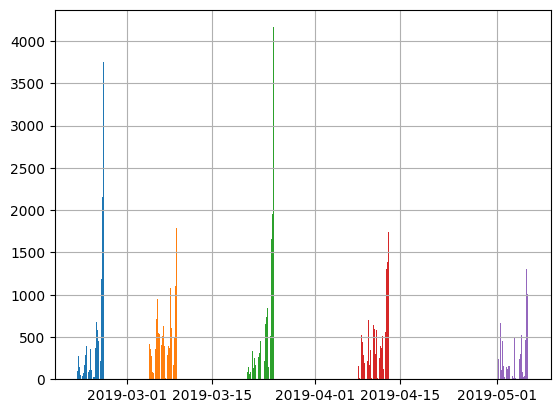

In [19]:
assignment_col = Cols.AssignmentID if Cols.AssignmentID in main_table.columns else problem_id_col
if "X-ClassID" not in main_table.columns:
    main_table.groupby(assignment_col)[timestamp_col].hist(bins=100)
else:
    classes = main_table["X-ClassID"].unique()
    classes = classes[~pd.isna(classes)]
    for class_id in classes:
        subset = main_table[main_table["X-ClassID"] == class_id]
        hist = subset.groupby(assignment_col)[timestamp_col].hist(bins=100)
        plt.title(f"Class {class_id}")
        plt.show()

In [20]:
import numpy as np
for i in main_table[timestamp_col].quantile(np.arange(0, 1.01, 0.01)).to_list():
    print(i)

2019-02-20 17:40:39
2019-02-21 18:59:26
2019-02-21 21:10:12.700000
2019-02-22 14:36:33.260000
2019-02-23 15:05:22
2019-02-23 19:36:47.150000128
2019-02-23 22:41:53.700000
2019-02-24 00:57:49.280000
2019-02-24 05:22:09
2019-02-24 15:49:48
2019-02-24 18:16:18
2019-02-24 19:22:04
2019-02-24 20:18:43.400000
2019-02-24 21:21:10
2019-02-24 22:18:57
2019-02-24 23:04:56
2019-02-25 00:00:59
2019-02-25 00:39:22
2019-02-25 01:20:38
2019-02-25 01:48:50
2019-02-25 02:23:34.800000
2019-02-25 02:55:14.429999872
2019-02-25 03:30:04
2019-02-25 04:06:05
2019-02-25 04:40:19.560000
2019-03-04 17:53:29
2019-03-04 21:52:47
2019-03-05 05:09:43
2019-03-05 17:42:09
2019-03-05 20:54:09
2019-03-05 23:37:08
2019-03-06 03:46:03.240000
2019-03-06 14:18:15
2019-03-06 16:49:21
2019-03-06 20:57:41
2019-03-07 02:06:58
2019-03-07 15:23:56
2019-03-07 20:55:55
2019-03-08 00:27:42
2019-03-08 03:12:50.370000128
2019-03-08 05:30:25.400000
2019-03-08 15:55:22
2019-03-08 20:41:00.920000
2019-03-08 22:07:23
2019-03-09 00:24:33


In [24]:

#get the data of the third quantile
max = main_table[timestamp_col].max()
min = main_table[timestamp_col].min()
range = max - min
# time_cutoff = min + range * early_percentage
time_cutoff = config.early_time
print(time_cutoff)
print(main_table[timestamp_col].min())
print(main_table[timestamp_col].max())

data_subset = main_table[main_table[timestamp_col] <= time_cutoff]
if Cols.AssignmentID in data_subset.columns:
    print("Assignment IDs:", data_subset[Cols.AssignmentID].unique())
if Cols.ProblemID in data_subset.columns:
    print("Problem IDs:", data_subset[Cols.ProblemID].unique())
print("Total number of rows:", len(data_subset))
print("Percent of logs: ", len(data_subset) / len(main_table) * 100)
if Cols.AssignmentID in data_subset.columns:
    print(f"Percent of assignments: {len(data_subset[Cols.AssignmentID].unique())} / {len(main_table[Cols.AssignmentID].unique())}")
if Cols.ProblemID in main_table.columns:
    print(f"Percent of problems: {len(data_subset[Cols.ProblemID].unique())} / {len(main_table[Cols.ProblemID].unique())}")
# Assignment IDs: [597 600]
# Problem IDs: [13 232 235 234 236   5 233   1   3  12  24 100 101  25 102  28  21  20  17  22]

2019-03-15 00:00:00
2019-02-20 17:40:39
2019-05-06 03:58:44
Assignment IDs: [439. 487.]
Problem IDs: [234  13  12 232 233   5 235  25 236  21   1 102   3  24 100  28 101  22
  17  20]
Total number of rows: 94876
Percent of logs:  47.068512179391774
Percent of assignments: 2 / 5
Percent of problems: 20 / 50


ProblemID
1      1.0
3      1.0
5      1.0
12     1.0
13     1.0
17     1.0
20     1.0
21     1.0
22     1.0
24     1.0
25     1.0
28     1.0
100    1.0
101    1.0
102    1.0
232    1.0
233    1.0
234    1.0
235    1.0
236    1.0
dtype: float64


C:\Users\twprice\AppData\Local\Temp\ipykernel_15696\1718260821.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  problem_percentages = main_table[main_table[problem_id_col].isin(included_problem_ids)].groupby(problem_id_col).apply(lambda x: (x[timestamp_col] < time_cutoff).mean())


<Axes: >

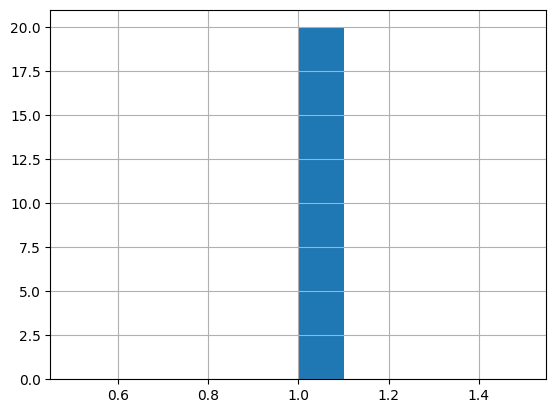

In [25]:
included_problem_ids = data_subset[problem_id_col].unique()
problem_percentages = main_table[main_table[problem_id_col].isin(included_problem_ids)].groupby(problem_id_col).apply(lambda x: (x[timestamp_col] < time_cutoff).mean())
problem_percentages.sort_values(ascending=False, inplace=True)
# Print the whole dataframe, ignoring row limits
with pd.option_context('display.max_rows', None):
    print(problem_percentages)

problem_percentages.hist()


In [26]:
if assignment_ids is not None:
    data_subset = data_subset[data_subset[Cols.AssignmentID].isin(assignment_ids)]

NameError: name 'assignment_ids' is not defined

In [27]:
precluded_problems = problem_percentages[problem_percentages < 0.5].index
len_before = len(data_subset)
data_subset = data_subset[~data_subset[problem_id_col].isin(precluded_problems)]
print(f"Precluded problems: {precluded_problems}")
print(f"Removed {100 - 100 * len(data_subset) / len_before:.2f}% of data")

if Cols.AssignmentID in data_subset.columns:
    print(f"Percent of assignments: {len(data_subset[Cols.AssignmentID].unique())} / {len(main_table[Cols.AssignmentID].unique())}")
if Cols.ProblemID in main_table.columns:
    print(f"Percent of problems: {len(data_subset[Cols.ProblemID].unique())} / {len(main_table[Cols.ProblemID].unique())}")

Precluded problems: Index([], dtype='int64', name='ProblemID')
Removed 0.00% of data
Percent of assignments: 2 / 5
Percent of problems: 20 / 50


In [28]:
grouping_cols = ["X-ClassID", Cols.TermID, Cols.SubjectID, problem_id_col]
grouping_cols = [col for col in grouping_cols if col in main_table.columns]

In [29]:
from analytics.metrics.errors import ErrorMetrics

error_results = None

error_metrics = ErrorMetrics(True,
                             compile_message_type_column=compile_error_type_column,
                             compile_event=compile_event,
                             compile_error_event=compile_error_event)

error_results = data_subset.groupby(grouping_cols).apply(error_metrics.calculate)
error_results.head()

C:\Users\twprice\AppData\Local\Temp\ipykernel_15696\1628737528.py:10: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  error_results = data_subset.groupby(grouping_cols).apply(error_metrics.calculate)


ErrorQuotient  \
SubjectID                        ProblemID                  
00c54f9462673d4c09d2a88121860841 1               0.000000   
                                 3               0.000000   
                                 5               0.000000   
                                 12              0.000000   
                                 13              0.545455   

                                            RepeatedErrorDensity  \
SubjectID                        ProblemID                         
00c54f9462673d4c09d2a88121860841 1                           0.0   
                                 3                           0.0   
                                 5                           0.0   
                                 12                          0.0   
                                 13                          0.0   

                                            FailedCompileCount  
SubjectID                        ProblemID                      
00c54f9462673d4c09d2a88121860841 1                         0.0  
                                 3                         0.0  
                                 5                         0.0  
                                 12                        0.0  
                                 13                        4.0

In [30]:
# Investigating a single Edwards 2021 student to see why EQ/RED are so low
# Errors tend not to be repeated and there are many successful runs
# data_subset[
#     (data_subset[Cols.SubjectID] == "Student1") &
#     (data_subset[Cols.AssignmentID] == "Assign7") &
#     ((data_subset[Cols.EventType] == EventType.CompileError) | (data_subset[Cols.EventType] == EventType.RunProgram))
# ].head(40)

In [31]:
# EQ is very low for codebench because most runs have no errors
# It's interesting/odd that EQ and RED don't correlate on this dataset

error_results.describe()

,ErrorQuotient,RepeatedErrorDensity,FailedCompileCount
count,6847.000000,6847.000000,6859.000000
mean,0.131724,0.420678,1.982359
std,0.233675,1.586132,4.050909
min,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000
50%,0.000000,0.000000,1.000000
75%,0.200000,0.000000,2.000000
max,1.000000,37.025641,60.000000


In [32]:
error_results.corr(method="spearman")

,ErrorQuotient,RepeatedErrorDensity,FailedCompileCount
ErrorQuotient,1.000000,0.823870,0.831691
RepeatedErrorDensity,0.823870,1.000000,0.709963
FailedCompileCount,0.831691,0.709963,1.000000


<Axes: ylabel='Frequency'>

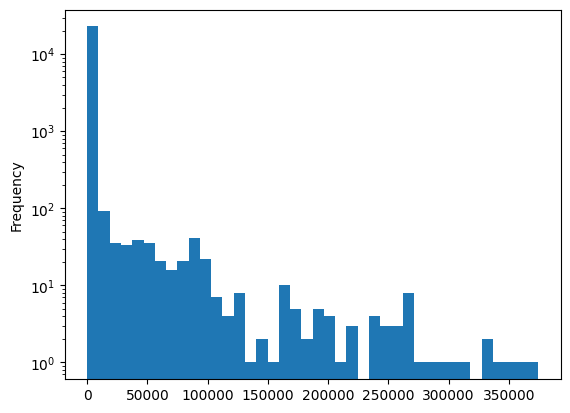

In [33]:
from analytics.metrics.time import TimeMetrics


diffs = TimeMetrics.get_all_diffs(data_subset, timestamp_col, grouping_cols)
diffs.DeltaSeconds[diffs.DeltaSeconds > 0].plot.hist(bins=40, log=True)

In [34]:
TimeMetrics.get_positive_diff_quantiles(data_subset, timestamp_col, grouping_cols) / 60

# Seems like 5 minutes (90th+ percentile) is a good cutoff for time spent on a problem between submissions
# 30m does seem to suggest that the student is not working on the problem

0.00       0.016667
0.25       0.283333
0.50       0.583333
0.75       1.416667
0.80       1.816667
0.85       2.483333
0.90       3.716667
0.95      10.483333
0.96      18.850000
0.97      40.325000
0.98     129.290000
0.99     792.715000
1.00    6236.666667
Name: DeltaSeconds, dtype: float64

In [35]:
from analytics.metrics.time import TimeMetrics

time_metrics = TimeMetrics(idle_gap, break_gap, True, timestamp_col)

result = data_subset.groupby(grouping_cols).apply(lambda x: time_metrics.calculate(x))
result

C:\Users\twprice\AppData\Local\Temp\ipykernel_15696\3223447471.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  result = data_subset.groupby(grouping_cols).apply(lambda x: time_metrics.calculate(x))


ActiveTime  PassiveTime  \
SubjectID                        ProblemID                            
00c54f9462673d4c09d2a88121860841 1                 0.0          0.0   
                                 3                 0.0          0.0   
                                 5                37.0          0.0   
                                 12                0.0          0.0   
                                 13              421.0          0.0   
...                                                ...          ...   
ffb72475a81de0e95b910ffad039f5c2 232            1630.0        571.0   
                                 233             120.0          0.0   
                                 234              40.0          0.0   
                                 235            1065.0          0.0   
                                 236               0.0          0.0   

                                            TotalTime  ActiveTimeAfterCorrect  \
SubjectID                        ProblemID                                      
00c54f9462673d4c09d2a88121860841 1                0.0                     0.0   
                                 3                0.0                     0.0   
                                 5               37.0                     0.0   
                                 12               0.0                    31.0   
                                 13             421.0                     0.0   
...                                               ...                     ...   
ffb72475a81de0e95b910ffad039f5c2 232           2201.0                     0.0   
                                 233            120.0                     0.0   
                                 234             40.0                     0.0   
                                 235           1065.0                     0.0   
                                 236              0.0                     0.0   

                                            #Breaks           StartTime  \
SubjectID                        ProblemID                                
00c54f9462673d4c09d2a88121860841 1                0 2019-02-24 05:13:03   
                                 3                0 2019-02-24 05:13:33   
                                 5                0 2019-02-24 05:09:54   
                                 12               0 2019-02-24 05:14:37   
                                 13               0 2019-02-24 04:27:49   
...                                             ...                 ...   
ffb72475a81de0e95b910ffad039f5c2 232              2 2019-02-24 07:04:21   
                                 233              0 2019-02-25 01:52:23   
                                 234              0 2019-02-25 01:25:54   
                                 235              0 2019-02-24 23:37:59   
                                 236              0 2019-02-25 01:32:22   

                                              FirstCorrectTime  \
SubjectID                        ProblemID                       
00c54f9462673d4c09d2a88121860841 1         2019-02-24 05:13:03   
                                 3         2019-02-24 05:13:33   
                                 5         2019-02-24 05:10:31   
                                 12        2019-02-24 05:14:37   
                                 13        2019-02-24 04:34:50   
...                                                        ...   
ffb72475a81de0e95b910ffad039f5c2 232       2019-02-25 01:18:45   
                                 233       2019-02-25 01:54:23   
                                 234       2019-02-25 01:26:34   
                                 235       2019-02-24 23:55:44   
                                 236       2019-02-25 01:32:22   

                                                       EndTime  
SubjectID                        ProblemID                      
00c54f9462673d4c09d2a88121860841 1         2019-02-24 05:13:03  
                                 3  

In [36]:
result.describe()

,ActiveTime,PassiveTime,TotalTime,ActiveTimeAfterCorrect,#Breaks,StartTime,FirstCorrectTime,EndTime
count,6859.000000,6859.000000,6859.000000,6859.000000,6859.000000,6859,6479,6859
mean,160.628809,97.085289,257.714098,4.661612,0.104534,2019-03-01 11:38:03.775477248,2019-03-01 09:39:10.098471936,2019-03-01 13:06:18.033095168
min,0.000000,0.000000,0.000000,0.000000,0.000000,2019-02-20 17:40:39,2019-02-20 21:17:01,2019-02-20 21:17:01
25%,0.000000,0.000000,0.000000,0.000000,0.000000,2019-02-24 20:35:45,2019-02-24 20:32:23.500000,2019-02-24 20:56:43.500000
50%,33.000000,0.000000,36.000000,0.000000,0.000000,2019-02-25 04:05:33,2019-02-25 03:55:47,2019-02-25 04:15:56
75%,181.500000,0.000000,227.000000,0.000000,0.000000,2019-03-07 05:29:36.500000,2019-03-07 04:49:30,2019-03-07 16:57:48.500000
max,5455.000000,5100.000000,8353.000000,2752.000000,7.000000,2019-03-09 04:58:46,2019-03-09 04:58:47,2019-03-09 04:58:59
std,325.835024,357.315763,581.078054,47.893497,0.398680,NaN,NaN,NaN


In [37]:
result.corr(method="spearman")

,ActiveTime,PassiveTime,TotalTime,ActiveTimeAfterCorrect,#Breaks,StartTime,FirstCorrectTime,EndTime
ActiveTime,1.000000,0.361758,0.960527,0.070177,0.333784,0.001079,-0.073257,0.029502
PassiveTime,0.361758,1.000000,0.531813,0.071606,0.316878,0.042037,-0.006719,0.070343
TotalTime,0.960527,0.531813,1.000000,0.075985,0.346215,0.010385,-0.064922,0.039835
ActiveTimeAfterCorrect,0.070177,0.071606,0.075985,1.000000,0.042829,0.000132,0.033387,0.011987
#Breaks,0.333784,0.316878,0.346215,0.042829,1.000000,0.049304,0.025832,0.118590
StartTime,0.001079,0.042037,0.010385,0.000132,0.049304,1.000000,0.839751,0.993101
FirstCorrectTime,-0.073257,-0.006719,-0.064922,0.033387,0.025832,0.839751,1.000000,0.837403
EndTime,0.029502,0.070343,0.039835,0.011987,0.118590,0.993101,0.837403,1.000000


In [38]:
result["FirstCorrectTime"].isna().mean()

np.float64(0.055401662049861494)

In [50]:
result["StartTime"].isna().mean()

np.float64(0.0)

In [51]:
from analytics.metrics.score import SubmissionScoreMetrics
from spec.enums import EventType

score_metrics = SubmissionScoreMetrics(submit_event)

subject_problem_score = data_subset.groupby(grouping_cols).apply(lambda x: score_metrics.calculate(x))


C:\Users\twprice\AppData\Local\Temp\ipykernel_27024\1178317524.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  subject_problem_score = data_subset.groupby(grouping_cols).apply(lambda x: score_metrics.calculate(x))


In [52]:
subject_problem_score.head()

Attempts  \
TermID    SubjectID                            ProblemID                      
Fall 2021 000f96b7-ba0e-43ce-a5c3-c8fc0a6406f0 lsn1_helloworld            1   
                                               lsn3_ascii                 3   
                                               lsn3_parking               2   
                                               lsn3_printpractice         1   
                                               lsn4_arrivaltime           3   

                                                                   FirstCorrect  \
TermID    SubjectID                            ProblemID                          
Fall 2021 000f96b7-ba0e-43ce-a5c3-c8fc0a6406f0 lsn1_helloworld             True   
                                               lsn3_ascii                 False   
                                               lsn3_parking               False   
                                               lsn3_printpractice          True   
                                               lsn4_arrivaltime           False   

                                                                   EverCorrect  \
TermID    SubjectID                            ProblemID                         
Fall 2021 000f96b7-ba0e-43ce-a5c3-c8fc0a6406f0 lsn1_helloworld            True   
                                               lsn3_ascii                 True   
                                               lsn3_parking               True   
                                               lsn3_printpractice         True   
                                               lsn4_arrivaltime           True   

                                                                   Attempted  \
TermID    SubjectID                            ProblemID                       
Fall 2021 000f96b7-ba0e-43ce-a5c3-c8fc0a6406f0 lsn1_helloworld          True   
                                               lsn3_ascii               True   
                                               lsn3_parking             True   
                                               lsn3_printpractice       True   
                                               lsn4_arrivaltime         True   

                                                                   MaxScore  \
TermID    SubjectID                            ProblemID                      
Fall 2021 000f96b7-ba0e-43ce-a5c3-c8fc0a6406f0 lsn1_helloworld        100.0   
                                               lsn3_ascii             100.0   
                                               lsn3_parking           100.0   
                                               lsn3_printpractice     100.0   
                                               lsn4_arrivaltime       100.0   

                                                                   MinScore  \
TermID    SubjectID                            ProblemID                      
Fall 2021 000f96b7-ba0e-43ce-a5c3-c8fc0a6406f0 lsn1_helloworld        100.0   
                                               lsn3_ascii               0.0   
                                               lsn3_parking             0.0   
                                               lsn3_printpractice      14.0   
                                               lsn4_arrivaltime         0.0   

                                                                    MeanScore  \
TermID    SubjectID                            ProblemID                        
Fall 2021 000f96b7-ba0e-43ce-a5c3-c8fc0a6406f0 lsn1_helloworld     100.000000   
                                               lsn3_ascii           33.333333   
                                               lsn3_parking         50.000000   
                                               lsn3_printpractice   14.000000   
                                               lsn4_arrivaltime     33.333333   

                                                                   TotalAttempts  
TermID    SubjectID                 

In [53]:
subject_problem_score.describe()

,Attempts,MaxScore,MinScore,MeanScore,TotalAttempts
count,18848.000000,18848.000000,18848.000000,18848.000000,18848.000000
mean,2.617572,97.318389,48.342211,59.194019,4.272071
std,3.989424,15.372840,45.982226,36.738807,5.639395
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,100.000000,0.000000,25.000000,1.000000
50%,1.000000,100.000000,40.000000,50.000000,2.000000
75%,3.000000,100.000000,100.000000,100.000000,5.000000
max,111.000000,100.000000,100.000000,100.000000,117.000000


In [56]:
all_features = pd.merge(
    result.reset_index(),
    subject_problem_score.reset_index(),
    on=grouping_cols,
    how="outer"
)
if error_results is not None:
    all_features = pd.merge(
        all_features,
        error_results.reset_index(),
        on=grouping_cols,
        how="outer"
    )
all_features.head()

,TermID,SubjectID,ProblemID,ActiveTime,PassiveTime,TotalTime,ActiveTimeAfterCorrect,#Breaks,StartTime,FirstCorrectTime,EndTime,Attempts,FirstCorrect,EverCorrect,Attempted,MaxScore,MinScore,MeanScore,TotalAttempts
0,Fall 2021,000f96b7-ba0e-43ce-a5c3-c8fc0a6406f0,lsn1_helloworld,0.0,0.0,0.0,291.0,0,2021-08-10 17:08:11,2021-08-10 17:08:11,2021-08-10 18:02:55,1,True,True,True,100.0,100.0,100.000000,7
1,Fall 2021,000f96b7-ba0e-43ce-a5c3-c8fc0a6406f0,lsn3_ascii,47.0,0.0,47.0,0.0,0,2021-08-18 14:07:12,2021-08-18 14:07:59,2021-08-18 14:08:22,3,False,True,True,100.0,0.0,33.333333,4
2,Fall 2021,000f96b7-ba0e-43ce-a5c3-c8fc0a6406f0,lsn3_parking,78.0,0.0,78.0,0.0,0,2021-08-16 17:23:23,2021-08-16 17:24:41,2021-08-19 12:51:53,2,False,True,True,100.0,0.0,50.000000,3
3,Fall 2021,000f96b7-ba0e-43ce-a5c3-c8fc0a6406f0,lsn3_printpractice,0.0,0.0,0.0,371.0,0,2021-08-19 12:53:35,2021-08-19 12:53:35,2021-08-19 13:00:10,1,True,True,True,100.0,14.0,14.000000,5
4,Fall 2021,000f96b7-ba0e-43ce-a5c3-c8fc0a6406f0,lsn4_arrivaltime,262.0,0.0,262.0,0.0,0,2021-08-18 14:13:26,2021-08-18 14:17:48,2021-08-19 13:04:32,3,False,True,True,100.0,0.0,33.333333,4


In [57]:
all_features.isna().mean()

TermID                    0.000000
SubjectID                 0.000000
ProblemID                 0.000000
ActiveTime                0.000000
PassiveTime               0.000000
TotalTime                 0.000000
ActiveTimeAfterCorrect    0.000000
#Breaks                   0.000000
StartTime                 0.000000
FirstCorrectTime          0.021647
EndTime                   0.000000
Attempts                  0.000000
FirstCorrect              0.000000
EverCorrect               0.000000
Attempted                 0.000000
MaxScore                  0.000000
MinScore                  0.000000
MeanScore                 0.000000
TotalAttempts             0.000000
dtype: float64

In [58]:
median_features = all_features.groupby(problem_id_col)[[TimeMetrics.ACTIVE_TIME, SubmissionScoreMetrics.MAX_SCORE]].median()
all_features_with_median = all_features.merge(
    median_features,
    on=problem_id_col,
    suffixes=("", "_median"),
    how="left"
)
all_features["AtLeatMedianActiveTime"] = (all_features[TimeMetrics.ACTIVE_TIME] >= all_features_with_median[TimeMetrics.ACTIVE_TIME + "_median"]) + 0
all_features["AtLeatMedianMaxScore"] = (all_features[SubmissionScoreMetrics.MAX_SCORE] >= all_features_with_median[SubmissionScoreMetrics.MAX_SCORE + "_median"]) + 0
all_features["HadEffort"] = all_features["AtLeatMedianActiveTime"] | all_features["AtLeatMedianMaxScore"]
all_features.describe()

,ActiveTime,PassiveTime,TotalTime,ActiveTimeAfterCorrect,#Breaks,StartTime,FirstCorrectTime,EndTime,Attempts,MaxScore,MinScore,MeanScore,TotalAttempts,AtLeatMedianActiveTime,AtLeatMedianMaxScore,HadEffort
count,18848.000000,18848.000000,18848.000000,18848.00000,18848.000000,18848,18440,18848,18848.000000,18848.000000,18848.000000,18848.000000,18848.000000,18848.000000,18848.000000,18848.000000
mean,110.563190,69.131526,179.694716,70.53056,0.074597,2021-08-22 08:19:25.935484160,2021-08-22 10:23:14.290292736,2021-08-22 18:14:20.068442368,2.617572,97.318389,48.342211,59.194019,4.272071,0.806027,0.966681,0.991405
min,0.000000,0.000000,0.000000,0.00000,0.000000,2021-07-22 21:04:55,2021-07-22 21:04:55,2021-07-23 16:04:12,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.00000,0.000000,2021-08-18 19:57:57.249999872,2021-08-18 21:06:22,2021-08-19 01:01:43,1.000000,100.000000,0.000000,25.000000,1.000000,1.000000,1.000000,1.000000
50%,0.000000,0.000000,0.000000,0.00000,0.000000,2021-08-22 20:54:24.500000,2021-08-22 22:26:05,2021-08-23 04:25:18.500000,1.000000,100.000000,40.000000,50.000000,2.000000,1.000000,1.000000,1.000000
75%,107.250000,0.000000,133.000000,0.00000,0.000000,2021-08-25 20:03:08.500000,2021-08-25 20:31:05,2021-08-26 03:00:44.500000,3.000000,100.000000,100.000000,100.000000,5.000000,1.000000,1.000000,1.000000
max,5736.000000,10063.000000,15394.000000,5598.00000,7.000000,2021-08-31 16:21:30,2021-08-31 16:21:39,2021-08-31 16:21:39,111.000000,100.000000,100.000000,100.000000,117.000000,1.000000,1.000000,1.000000
std,262.362347,299.526778,483.402096,224.28655,0.338311,NaN,NaN,NaN,3.989424,15.372840,45.982226,36.738807,5.639395,0.395418,0.179473,0.092313


In [59]:
all_features_z = all_features.copy()

time_cols = [
    TimeMetrics.START_TIME,
    TimeMetrics.FIRST_CORRECT_TIME,
    TimeMetrics.END_TIME,
]

all_features_z[time_cols] = all_features_z[time_cols].astype('int64') / 1e9
numeric_cols = all_features_z.select_dtypes(include=["number"]).columns
# remove the grouping columns from numeric_cols
numeric_cols = numeric_cols.difference(grouping_cols)
all_features_z[numeric_cols] = all_features_z.groupby(problem_id_col)[numeric_cols].transform(lambda x: (x - x.mean()) / (x.std() if x.std() > 0 else 1))


In [60]:
all_features_z.head()

,TermID,SubjectID,ProblemID,ActiveTime,PassiveTime,TotalTime,ActiveTimeAfterCorrect,#Breaks,StartTime,FirstCorrectTime,...,FirstCorrect,EverCorrect,Attempted,MaxScore,MinScore,MeanScore,TotalAttempts,AtLeatMedianActiveTime,AtLeatMedianMaxScore,HadEffort
0,Fall 2021,000f96b7-ba0e-43ce-a5c3-c8fc0a6406f0,lsn1_helloworld,-0.127403,-0.056221,-0.102364,2.049407,-0.076117,0.101343,0.087219,...,True,True,True,0.000000,0.069730,0.069040,3.117450,0.000000,0.000000,0.000000
1,Fall 2021,000f96b7-ba0e-43ce-a5c3-c8fc0a6406f0,lsn3_ascii,-0.463237,-0.271449,-0.468991,-0.178388,-0.308825,0.041088,0.344434,...,False,True,True,0.344429,-0.556217,-0.152882,-0.302361,-1.013373,0.344429,0.258551
2,Fall 2021,000f96b7-ba0e-43ce-a5c3-c8fc0a6406f0,lsn3_parking,-0.315964,-0.319092,-0.367951,-0.340733,-0.323583,-0.000893,0.230472,...,False,True,True,0.239820,-0.599470,0.263213,-0.467927,0.999129,0.242771,0.179771
3,Fall 2021,000f96b7-ba0e-43ce-a5c3-c8fc0a6406f0,lsn3_printpractice,-0.302018,-0.210509,-0.292998,0.233054,-0.178293,1.321915,0.085228,...,True,True,True,0.201103,-0.662610,-0.759403,-0.309218,0.000000,0.216583,0.000000
4,Fall 2021,000f96b7-ba0e-43ce-a5c3-c8fc0a6406f0,lsn4_arrivaltime,0.075587,-0.346979,-0.170451,-0.210077,-0.362892,-0.085627,0.166948,...,False,True,True,0.166960,-0.550075,-0.377617,-0.155353,0.997456,0.166960,0.131308


In [61]:
all_features_z.RepeatedErrorDensity.isna().mean()

AttributeError: 'DataFrame' object has no attribute 'RepeatedErrorDensity'

In [62]:
all_na_eq = all_features.groupby(Cols.SubjectID).ErrorQuotient.apply(lambda x: pd.isna(x).all())
all_na_eq = all_na_eq[all_na_eq]
all_na_eq

AttributeError: 'DataFrameGroupBy' object has no attribute 'ErrorQuotient'

In [63]:
# In CWO, this student attempted all of 1 problem, got and error and gave up
# I think assigning a 1 makes more sense than a 0... but 0 is more generic and
# it's rare enough I'm not going to worry about it right now
data_subset[data_subset[Cols.SubjectID].isin(all_na_eq.index)]

NameError: name 'all_na_eq' is not defined

In [64]:
merge_cols = grouping_cols.copy()
merge_cols.remove(problem_id_col)
merge_cols = [col for col in merge_cols if col in all_features_z.columns]

subject_means = all_features_z.drop(problem_id_col, axis=1).groupby(merge_cols).mean()
# In theory this can happen is someone only has NA for all problems
# This apparently happened with EQ in CWO...

# For EQ, having no attempts with compile errors should give you
# the max value (whatever 1 is after normalization)
for col in [ErrorMetrics.ERROR_QUOTIENT]:
    max_val = subject_means[col].max()
    subject_means.iloc[:, subject_means.columns.get_loc(col)] = subject_means[col].fillna(max_val)

# But for RED it should be the minimum value (normalized 0)
for col in [ErrorMetrics.REPEATED_ERROR_DENSITY, SubmissionScoreMetrics.MAX_SCORE, SubmissionScoreMetrics.MEAN_SCORE, SubmissionScoreMetrics.MIN_SCORE]:
    min_val = subject_means[col].min()
    subject_means.iloc[:, subject_means.columns.get_loc(col)] = subject_means[col].fillna(min_val)

subject_means.head()

KeyError: 'ErrorQuotient'

In [55]:
subject_totals = all_features_z.drop(problem_id_col, axis=1).groupby(merge_cols).sum()
subject_totals.head()

ActiveTime  PassiveTime  TotalTime  \
X-ClassID   SubjectID                                       
945591435.0 112044560   -0.494177    -0.569686  -0.561906   
            158242931   -0.245766     1.768031   0.543192   
            188644686  -10.831146    -9.040990 -11.231504   
            280846303   -0.380819    -0.482743  -0.437578   
            414686080   32.651084    27.628571  32.588833   

                       ActiveTimeAfterCorrect   #Breaks  StartTime  \
X-ClassID   SubjectID                                                
945591435.0 112044560               -0.175849 -0.478578   1.677975   
            158242931               -0.795100  1.013290   3.239274   
            188644686               -4.819251 -7.859897 -14.116882   
            280846303               -0.246561 -0.266315   0.982964   
            414686080               -7.460919  9.530372  19.513427   

                       FirstCorrectTime    EndTime  Attempts  FirstCorrect  \
X-ClassID   SubjectID                                                        
945591435.0 112044560         -3.215685   1.274810 -0.691515             0   
            158242931         -2.709643   3.243871 -2.155776             1   
            188644686          5.366221 -17.043834 -7.454400            16   
            280846303         -3.606372   0.663749 -0.320550             0   
            414686080         -7.455778  15.078404  6.553357            14   

                       ...  MaxScore   MinScore  MeanScore  TotalAttempts  \
X-ClassID   SubjectID  ...                                                  
945591435.0 112044560  ... -3.215685  -1.028469  -1.602820      -0.730212   
            158242931  ... -2.709690  -0.305075  -1.298547      -2.071009   
            188644686  ...  6.148448   9.279542  11.348147      -7.804580   
            280846303  ... -3.758503  -0.966686  -1.669050      -0.337874   
            414686080  ... -8.148268 -17.485980 -19.859757       3.482820   

                       ErrorQuotient  RepeatedErrorDensity  \
X-ClassID   SubjectID                                        
945591435.0 112044560       0.000000              0.000000   
            158242931       0.806915             -0.549511   
            188644686      -3.522023             -3.701875   
            280846303       0.000000              0.000000   
            414686080       3.257636              3.145126   

                       FailedCompileCount  AtLeatMedianActiveTime  \
X-ClassID   SubjectID                                               
945591435.0 112044560           -0.730212                0.000000   
            158242931           -2.071009               -1.077957   
            188644686           -7.804580               -9.940308   
            280846303           -0.337874                0.991155   
            414686080            3.482820               23.578694   

                       AtLeatMedianMaxScore  HadEffort  
X-ClassID   SubjectID                                   
945591435.0 112044560             -3.215685   0.000000  
            158242931             -2.709690  -2.916243  
            188644686              6.148448   2.023041  
            280846303             -3.606372   0.155238  
            414686080             -8.034059   6.539206  

[5 rows x 22 columns]

In [56]:
subject_features = pd.merge(
    subject_means.reset_index(),
    subject_totals.reset_index(),
    on=merge_cols,
    how="outer",
    suffixes=('_mean', '_sum')
)
subject_features.head()

,X-ClassID,SubjectID,ActiveTime_mean,PassiveTime_mean,TotalTime_mean,ActiveTimeAfterCorrect_mean,#Breaks_mean,StartTime_mean,FirstCorrectTime_mean,EndTime_mean,...,MaxScore_sum,MinScore_sum,MeanScore_sum,TotalAttempts_sum,ErrorQuotient_sum,RepeatedErrorDensity_sum,FailedCompileCount_sum,AtLeatMedianActiveTime_sum,AtLeatMedianMaxScore_sum,HadEffort_sum
0,945591435.0,112044560,-0.494177,-0.569686,-0.561906,-0.175849,-0.478578,1.677975,-3.215685,1.274810,...,-3.215685,-1.028469,-1.602820,-0.730212,0.000000,0.000000,-0.730212,0.000000,-3.215685,0.000000
1,945591435.0,158242931,-0.081922,0.589344,0.181064,-0.265033,0.337763,1.079758,-0.903214,1.081290,...,-2.709690,-0.305075,-1.298547,-2.071009,0.806915,-0.549511,-2.071009,-1.077957,-2.709690,-2.916243
2,945591435.0,188644686,-0.492325,-0.410954,-0.510523,-0.219057,-0.357268,-0.641676,0.243919,-0.774720,...,6.148448,9.279542,11.348147,-7.804580,-3.522023,-3.701875,-7.804580,-9.940308,6.148448,2.023041
3,945591435.0,280846303,-0.380819,-0.482743,-0.437578,-0.246561,-0.266315,0.982964,-3.606372,0.663749,...,-3.758503,-0.966686,-1.669050,-0.337874,0.000000,0.000000,-0.337874,0.991155,-3.606372,0.155238
4,945591435.0,414686080,0.777407,0.657823,0.775925,-0.177641,0.226914,0.464605,-0.177519,0.359010,...,-8.148268,-17.485980,-19.859757,3.482820,3.257636,3.145126,3.482820,23.578694,-8.034059,6.539206


In [57]:
subject_features.isna().mean()[subject_features.isna().mean() != 0]

Series([], dtype: float64)

In [58]:
assert subject_features.isna().mean().mean() == 0

In [59]:
subject_feautres_z = subject_features.copy()
numeric_cols = subject_feautres_z.select_dtypes(include=["number"]).columns
numeric_cols = numeric_cols.difference(merge_cols)
subject_feautres_z[numeric_cols] = subject_feautres_z[numeric_cols].apply(lambda x: (x - x.mean()) / (x.std() if x.std() > 0 else 1), axis=0)
subject_feautres_z.head()

,X-ClassID,SubjectID,ActiveTime_mean,PassiveTime_mean,TotalTime_mean,ActiveTimeAfterCorrect_mean,#Breaks_mean,StartTime_mean,FirstCorrectTime_mean,EndTime_mean,...,MaxScore_sum,MinScore_sum,MeanScore_sum,TotalAttempts_sum,ErrorQuotient_sum,RepeatedErrorDensity_sum,FailedCompileCount_sum,AtLeatMedianActiveTime_sum,AtLeatMedianMaxScore_sum,HadEffort_sum
0,945591435.0,112044560,-0.514863,-0.862984,-0.658383,-0.288089,-0.855853,2.029474,-1.785601,1.687253,...,-0.357694,-0.094745,-0.135168,-0.065853,7.674984e-17,2.903202e-17,-0.065853,3.778503e-17,-0.358776,0.000000
1,945591435.0,158242931,0.177045,1.448710,0.612855,-0.582442,1.172337,1.266715,-0.108300,1.425594,...,-0.301410,-0.028104,-0.109508,-0.186770,2.379455e-01,-8.756451e-02,-0.186770,-9.780779e-02,-0.302322,-0.479126
2,945591435.0,188644686,-0.511755,-0.546391,-0.570465,-0.430697,-0.554460,-0.928207,0.723748,-1.083925,...,0.683917,0.854854,0.957004,-0.703840,-1.038585e+00,-5.898931e-01,-0.703840,-9.019284e-01,0.685987,0.332377
3,945591435.0,280846303,-0.324609,-0.689574,-0.445654,-0.521474,-0.328490,1.143298,-2.068977,0.861034,...,-0.418074,-0.089053,-0.140753,-0.030470,7.674984e-17,2.903202e-17,-0.030470,8.993188e-02,-0.402365,0.025505
4,945591435.0,414686080,1.619299,1.585293,1.630674,-0.294003,0.896932,0.482363,0.418067,0.448995,...,-0.906365,-1.610852,-1.674800,0.314091,9.606221e-01,5.011753e-01,0.314091,2.139400e+00,-0.896366,1.074363


In [60]:
grades = dataset.get_link_table(grades_link_table)
grades.head()

,CourseID,SubjectID,URL,approved,final-grade
0,919753123,2596793261,Resources/FinalGrade/919753123_2596793261.yaml,False,0.00
1,919753123,3143505766,Resources/FinalGrade/919753123_3143505766.yaml,False,0.00
2,919753123,3624632776,Resources/FinalGrade/919753123_3624632776.yaml,False,0.44
3,919753123,3215542955,Resources/FinalGrade/919753123_3215542955.yaml,False,3.38
4,919753123,904953019,Resources/FinalGrade/919753123_904953019.yaml,False,0.00


In [61]:
grades.rename(columns={
    grades_col: "Grade",
    # Edwards 2019 calls it Group
    "Group": "X-ClassID",
    # CodeBench has this mislabeled
    "CourseID": "X-ClassID"},
inplace=True)

# Drop 0 grades, since they're likely students who skipped the test
print(f"Dropping {grades[grades['Grade'] <= 0].shape[0]} rows with 0 grades")
grades = grades[grades["Grade"] > 0]

Dropping 189 rows with 0 grades


In [62]:
print(f"Merging on columns: {merge_cols}")

subject_feautres_labeled = pd.merge(
    subject_feautres_z,
    grades[merge_cols + ["Grade"]],
    on=merge_cols,
    how="inner",
)

Merging on columns: ['X-ClassID', <MainTableColumns.SubjectID: 'SubjectID'>]


In [63]:
print(subject_features.shape)
subject_feautres_labeled.head()

(273, 46)


,X-ClassID,SubjectID,ActiveTime_mean,PassiveTime_mean,TotalTime_mean,ActiveTimeAfterCorrect_mean,#Breaks_mean,StartTime_mean,FirstCorrectTime_mean,EndTime_mean,...,MinScore_sum,MeanScore_sum,TotalAttempts_sum,ErrorQuotient_sum,RepeatedErrorDensity_sum,FailedCompileCount_sum,AtLeatMedianActiveTime_sum,AtLeatMedianMaxScore_sum,HadEffort_sum,Grade
0,945591435.0,158242931,0.177045,1.448710,0.612855,-0.582442,1.172337,1.266715,-0.108300,1.425594,...,-0.028104,-0.109508,-0.186770,0.237946,-0.087565,-0.186770,-0.097808,-0.302322,-0.479126,1.49
1,945591435.0,188644686,-0.511755,-0.546391,-0.570465,-0.430697,-0.554460,-0.928207,0.723748,-1.083925,...,0.854854,0.957004,-0.703840,-1.038585,-0.589893,-0.703840,-0.901928,0.685987,0.332377,8.75
2,945591435.0,414686080,1.619299,1.585293,1.630674,-0.294003,0.896932,0.482363,0.418067,0.448995,...,-1.610852,-1.674800,0.314091,0.960622,0.501175,0.314091,2.139400,-0.896366,1.074363,5.66
3,945591435.0,530793764,0.990010,1.225300,1.079073,-0.158475,0.343816,0.591473,0.411013,0.589181,...,0.607262,0.375839,-0.893734,0.250502,-0.569959,-0.893734,0.355421,-0.644424,-0.083449,3.12
4,945591435.0,873175644,2.180400,2.315075,2.131847,-0.802892,0.134520,1.576508,-1.049440,1.559539,...,-0.177767,-0.218191,0.304906,0.161521,0.390559,0.304906,0.095874,-0.491079,0.056451,3.42


In [64]:
assert subject_feautres_labeled.groupby(merge_cols).Grade.count().max() == 1

In [65]:
print(len(subject_feautres_labeled))
dir = os.path.join(dataset.data_config.root_path, f"analysis{output_suffix}")
if not os.path.exists(dir):
    os.makedirs(dir)
subject_feautres_labeled.to_csv(os.path.join(dir, f"subject_features.csv"), index=False)

205
